<a href="https://colab.research.google.com/github/ladams1204/SportsBookEdge/blob/main/04_first_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install nba_api xgboost shap --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.6/322.6 kB 6.3 MB/s eta 0:00:00


In [2]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import shap

In [4]:
from nba_api.stats.endpoints import playergamelog
from nba_api.stats.static import players
import time

conn = sqlite3.connect('sportsbook.db')
cursor = conn.cursor()

cursor.execute('''
CREATE TABLE IF NOT EXISTS nba_player_games (
    game_id TEXT, player_id INTEGER, player_name TEXT, game_date TEXT,
    matchup TEXT, wl TEXT, minutes INTEGER, points INTEGER, rebounds INTEGER,
    assists INTEGER, steals INTEGER, blocks INTEGER, turnovers INTEGER,
    fgm INTEGER, fga INTEGER, fg3m INTEGER, fg3a INTEGER, plus_minus INTEGER,
    season TEXT, PRIMARY KEY (game_id, player_id)
)
''')
conn.commit()

target_players = [
    "LeBron James", "Stephen Curry", "Nikola Jokic", "Luka Doncic",
    "Jayson Tatum", "Giannis Antetokounmpo", "Shai Gilgeous-Alexander",
    "Kevin Durant", "Anthony Edwards", "Joel Embiid",
    "Devin Booker", "Damian Lillard", "Jimmy Butler", "Paul George",
    "Donovan Mitchell", "Trae Young", "De'Aaron Fox", "Ja Morant",
    "Anthony Davis", "Victor Wembanyama"
]

def pull_player_season(player_name, season):
    matches = players.find_players_by_full_name(player_name)
    if not matches: return 0
    player = matches[0]
    log = playergamelog.PlayerGameLog(player_id=player['id'], season=season)
    df = log.get_data_frames()[0]
    if len(df) == 0: return 0
    df['SEASON'] = season
    df['PLAYER_NAME'] = player['full_name']
    df = df.rename(columns={
        'Game_ID': 'game_id', 'Player_ID': 'player_id',
        'PLAYER_NAME': 'player_name', 'GAME_DATE': 'game_date',
        'MATCHUP': 'matchup', 'WL': 'wl', 'MIN': 'minutes',
        'PTS': 'points', 'REB': 'rebounds', 'AST': 'assists',
        'STL': 'steals', 'BLK': 'blocks', 'TOV': 'turnovers',
        'FGM': 'fgm', 'FGA': 'fga', 'FG3M': 'fg3m', 'FG3A': 'fg3a',
        'PLUS_MINUS': 'plus_minus', 'SEASON': 'season'
    })[['game_id', 'player_id', 'player_name', 'game_date', 'matchup', 'wl',
        'minutes', 'points', 'rebounds', 'assists', 'steals', 'blocks',
        'turnovers', 'fgm', 'fga', 'fg3m', 'fg3a', 'plus_minus', 'season']]
    n = 0
    for _, row in df.iterrows():
        try:
            cursor.execute(f"INSERT INTO nba_player_games VALUES ({','.join(['?']*19)})", tuple(row))
            n += 1
        except sqlite3.IntegrityError:
            pass
    conn.commit()
    return n

print("Pulling data (this will take ~2 minutes)...")
total = 0
for season in ['2024-25', '2025-26']:
    for name in target_players:
        total += pull_player_season(name, season)
        time.sleep(0.6)
print(f"Data pulled: {total} rows inserted")

# Load and clean
df = pd.read_sql("SELECT * FROM nba_player_games ORDER BY player_id, game_date", conn)
df['game_date'] = pd.to_datetime(df['game_date'])
for col in ['minutes', 'points', 'rebounds', 'assists', 'steals', 'blocks',
            'turnovers', 'fgm', 'fga', 'fg3m', 'fg3a', 'plus_minus']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.sort_values(['player_id', 'game_date']).reset_index(drop=True)

# Build features (same as Session 3)
df['pts_avg_10'] = df.groupby('player_id')['points'].transform(
    lambda x: x.shift(1).rolling(10, min_periods=3).mean())
df['pts_avg_20'] = df.groupby('player_id')['points'].transform(
    lambda x: x.shift(1).rolling(20, min_periods=5).mean())
df['reb_avg_10'] = df.groupby('player_id')['rebounds'].transform(
    lambda x: x.shift(1).rolling(10, min_periods=3).mean())
df['ast_avg_10'] = df.groupby('player_id')['assists'].transform(
    lambda x: x.shift(1).rolling(10, min_periods=3).mean())
df['min_avg_10'] = df.groupby('player_id')['minutes'].transform(
    lambda x: x.shift(1).rolling(10, min_periods=3).mean())
df['rest_days'] = df.groupby('player_id')['game_date'].transform(
    lambda x: (x - x.shift(1)).dt.days)
df['is_b2b'] = (df['rest_days'] == 1).astype(int)
df['is_home'] = df['matchup'].str.contains('vs').astype(int)

print(f"Feature-built DataFrame: {len(df)} rows, {len(df.columns)} columns")
print(f"Date range: {df['game_date'].min().date()} to {df['game_date'].max().date()}")

Pulling data (this will take ~2 minutes)...
Data pulled: 2149 rows inserted
Feature-built DataFrame: 2149 rows, 27 columns
Date range: 2024-10-22 to 2026-04-12


In [5]:
feature_cols = [
    'pts_avg_10', 'pts_avg_20', 'reb_avg_10', 'ast_avg_10',
    'min_avg_10', 'rest_days', 'is_b2b', 'is_home'
]

In [6]:
target_col = 'points'


In [7]:
model_df = df.dropna(subset=feature_cols + [target_col]).copy()

print(f"Original rows: {len(df)}")
print(f"Rows usable for modeling: {len(model_df)}")
print(f"Rows dropped (insufficient history): {len(df) - len(model_df)}")

Original rows: 2149
Rows usable for modeling: 2049
Rows dropped (insufficient history): 100


In [8]:
print(f"\nPoints distribution:")
print(f"  Mean:   {model_df['points'].mean():.1f}")
print(f"  Median: {model_df['points'].median():.1f}")
print(f"  Min:    {model_df['points'].min()}")
print(f"  Max:    {model_df['points'].max()}")
print(f"  Std:    {model_df['points'].std():.1f}")


Points distribution:
  Mean:   25.5
  Median: 25.0
  Min:    0
  Max:    61
  Std:    9.1


In [10]:
cutoff = pd.to_datetime('2026-03-01')

train_df = model_df[model_df['game_date'] < cutoff].copy()
test_df = model_df[model_df['game_date'] >= cutoff].copy()

print(f"Training set: {len(train_df)} games (before {cutoff.date()})")
print(f"Test set:     {len(test_df)} games (on or after {cutoff.date()})")

Training set: 1819 games (before 2026-03-01)
Test set:     230 games (on or after 2026-03-01)


In [11]:
X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print(f"\nX_train shape: {X_train.shape}  (rows, columns)")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape: (1819, 8)  (rows, columns)
y_train shape: (1819,)
X_test shape:  (230, 8)
y_test shape:  (230,)


In [14]:
model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

# Train it
model.fit(X_train, y_train)

print("Model trained successfully")
print(f"Number of trees: {model.n_estimators}")


Model trained successfully
Number of trees: 200


In [16]:
# Initialize the XGBoost regressor
model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

# Train it
model.fit(X_train, y_train)

print("Model trained successfully")
print(f"Number of trees: {model.n_estimators}")

Model trained successfully
Number of trees: 200


In [17]:
python# Predict on both training and test data
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

# Calculate metrics
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{label}:")
    print(f"  MAE:  {mae:.2f} points  (average absolute error per game)")
    print(f"  RMSE: {rmse:.2f} points  (penalizes big misses more)")
    print(f"  R²:   {r2:.3f}           (1.0 = perfect, 0 = no better than guessing mean)")
    print()

evaluate(y_train, train_preds, "TRAINING SET")
evaluate(y_test, test_preds, "TEST SET")

# Sanity check: what's the "guess the mean" baseline?
baseline_pred = np.full_like(y_test, y_train.mean(), dtype=float)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
print(f"Baseline (always predict training mean): RMSE = {baseline_rmse:.2f}")
print(f"If our test RMSE < {baseline_rmse:.2f}, the model learned something real.")

NameError: name 'python' is not defined

In [18]:
baseline_pred = np.full_like(y_test, y_train.mean(), dtype=float)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
print(f"Baseline (always predict training mean): RMSE = {baseline_rmse:.2f}")
print(f"Your model's test RMSE: 8.81")
print(f"Improvement over baseline: {baseline_rmse - 8.81:.2f} points")

Baseline (always predict training mean): RMSE = 9.11
Your model's test RMSE: 8.81
Improvement over baseline: 0.30 points


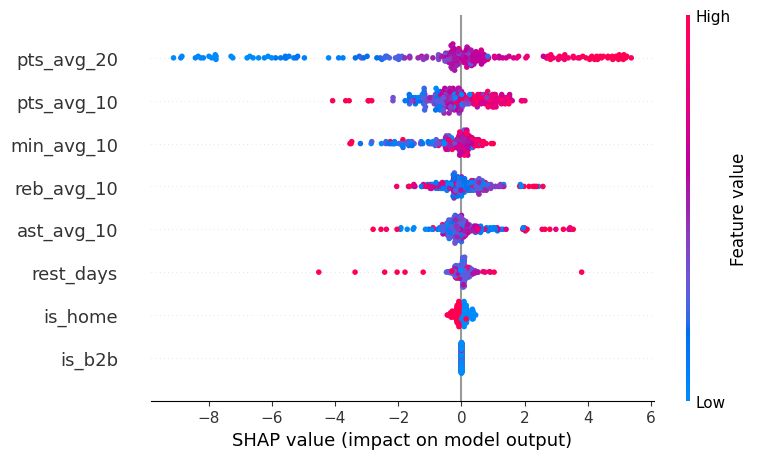

In [19]:
# SHAP tells us: which features did the model rely on most, and in what direction?
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot: all features, ranked by importance
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=True)

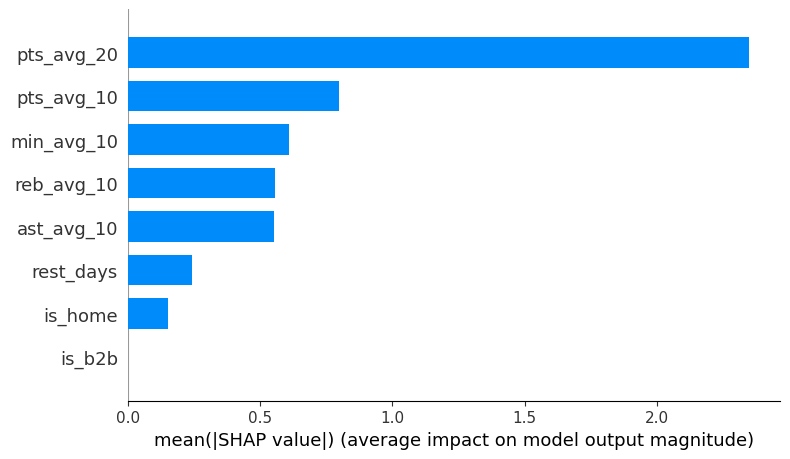

In [20]:
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, plot_type="bar", show=True)

In [21]:
# Show actual predictions vs. actual results for 15 random test games
test_results = test_df[['player_name', 'game_date', 'matchup', 'points']].copy()
test_results['predicted'] = test_preds.round(1)
test_results['error'] = (test_results['points'] - test_results['predicted']).round(1)
test_results['abs_error'] = test_results['error'].abs()

# Show 15 random games with the biggest misses
print("=== 15 biggest prediction misses ===")
big_misses = test_results.nlargest(15, 'abs_error')[
    ['player_name', 'game_date', 'matchup', 'points', 'predicted', 'error']
]
print(big_misses.to_string(index=False))

# Show the model's calibration
print("\n=== Best 5 predictions (closest to reality) ===")
best_preds = test_results.nsmallest(5, 'abs_error')[
    ['player_name', 'game_date', 'matchup', 'points', 'predicted', 'error']
]
print(best_preds.to_string(index=False))

=== 15 biggest prediction misses ===
      player_name  game_date     matchup  points  predicted  error
      Luka Dončić 2026-03-19   LAL @ MIA      60  31.299999   28.7
      Paul George 2026-04-01   PHI @ WAS      39  16.400000   22.6
  Anthony Edwards 2026-04-03   MIN @ PHI       8  29.799999  -21.8
Victor Wembanyama 2026-03-30 SAS vs. CHI      41  20.400000   20.6
      Luka Dončić 2026-03-25   LAL @ IND      43  23.100000   19.9
     Nikola Jokić 2026-04-08 DEN vs. MEM      14  33.400002  -19.4
     Devin Booker 2026-03-12   PHX @ IND      43  23.600000   19.4
      Luka Dončić 2026-03-27 LAL vs. BKN      41  21.799999   19.2
 Donovan Mitchell 2026-03-27 CLE vs. MIA       6  24.799999  -18.8
      Luka Dončić 2026-03-12 LAL vs. CHI      51  32.400002   18.6
     Nikola Jokić 2026-03-11 DEN vs. HOU      16  33.900002  -17.9
      Luka Dončić 2026-03-31 LAL vs. CLE      42  24.100000   17.9
     Nikola Jokić 2026-04-01   DEN @ UTA      15  32.500000  -17.5
Victor Wembanyama 2026-04